In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden
from collections import defaultdict
import os
import numpy as np 

# Keep your existing constants
ONE_COL_WIDTH_INCH = 2.75
TWO_COL_WIDTH_INCH = 5.5
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden

plt.style.use("lamalab.mplstyle")


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [3]:
def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    filtered_x = [val for val in x if val is not None]
    if filtered_x:  
        x_min, x_max = np.min(filtered_x), np.max(filtered_x)  
    else:  
        x_min, x_max = 0, 1  # Default values or handle accordingly

    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["left"].set_bounds(y_min, y_max)
    ax.spines["bottom"].set_bounds(x_min, x_max)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)


In [10]:


def plot_grouped_geometry_composition_coupling(json_file_path):
    """
    Loads data from a JSON file and creates a single grouped bar chart.
    X-axis: Properties.
    Groups: Bars for each representation type, showing (geometry_contribution - composition_contribution).

    Args:
        json_file_path (str): The path to the JSON file.
    """
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file '{json_file_path}' is not a valid JSON file.")
        return

    output_dir = "property_coupling_plots"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Plot will be saved in the '{output_dir}' directory.")

    # --- Step 1: Collect and structure data ---
    # processed_data will look like: {property_name: {representation_name: coupling_value}}
    processed_data = {}
    # Maintain order of properties as they appear in the JSON for the x-axis
    property_names_ordered = list(data.keys())
    all_representation_names_set = set()

    for property_name, representations_data in data.items():
        if property_name not in processed_data:
            processed_data[property_name] = {}

        # Sort representation keys for consistent internal order when collecting unique names
        sorted_rep_keys_for_property = sorted(representations_data.keys())

        for rep_key in sorted_rep_keys_for_property:
            rep_data = representations_data[rep_key]
            if "geometry_contribution" in rep_data and "composition_contribution" in rep_data:
                geom_contrib = rep_data["geometry_contribution"]
                comp_contrib = rep_data["composition_contribution"]
                coupling = geom_contrib - comp_contrib
                processed_data[property_name][rep_key] = coupling
                all_representation_names_set.add(rep_key)
            else:
                print(f"Warning: Missing contribution data for {property_name} -> {rep_key}")

    if not processed_data or not all_representation_names_set:
        print("No valid data to plot after processing.")
        return

    # Convert set to list and sort for consistent plotting order and legend
    sorted_representation_names = sorted(list(all_representation_names_set))
    num_properties = len(property_names_ordered)
    num_representations = len(sorted_representation_names)

    if num_properties == 0 or num_representations == 0:
        print("Not enough properties or representations to create a grouped bar chart.")
        return

    # --- Step 2: Plotting ---
    fig, ax = plt.subplots(figsize=(max(10, num_properties * num_representations * 0.5), 8)) # Dynamic width

    # Define colors for representations
    # The AttributeError was due to 'color_palette'. We use 'color' and provide a list of colors.
    if num_representations > 0:
        # Using a colormap to get distinct colors. 'tab10' or 'Paired' are good for categorical.
        cmap = plt.cm.get_cmap('Paired', num_representations)
        colors = [cmap(i) for i in range(num_representations)]
    else:
        colors = ['blue'] # Fallback, though should not be reached if num_representations is 0

    # Calculate bar width and positions
    total_width_for_all_bars_in_group = 0.8  # How much of the x-tick space the bars for one property will occupy
    bar_width = total_width_for_all_bars_in_group / num_representations
    
    # X-coordinates for the center of each group (property)
    index = np.arange(num_properties)

    for i, rep_name in enumerate(sorted_representation_names):
        coupling_values_for_this_rep = []
        for prop_name in property_names_ordered:
            # Get coupling value, default to 0 if not present for this property/rep combo
            value = processed_data.get(prop_name, {}).get(rep_name, 0) # Use 0 for missing data
            coupling_values_for_this_rep.append(value)

        # Calculate x-position for this representation's bars across all properties
        # The group of bars for a property is centered at 'index'.
        # Offset for this specific bar within its group:
        # (i * bar_width) shifts right for each subsequent representation
        # - total_width_for_all_bars_in_group / 2 centers the whole group
        # + bar_width / 2 centers the bar itself over its calculated left edge
        bar_positions = index - (total_width_for_all_bars_in_group / 2) + (i * bar_width) + (bar_width / 2)
        
        rects = ax.bar(bar_positions, coupling_values_for_this_rep, bar_width,
                       label=rep_name.replace("_", " ").title(),
                       color=colors[i % len(colors)]) # Use the i-th color, cycle if needed

        # Add value labels on top of each bar
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if height >= 0 else -12),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom' if height >=0 else 'top', fontsize=7, rotation=0) # Smaller font

    # --- Step 3: Customize plot ---
    ax.set_xlabel("Property", fontsize=14)
    ax.set_ylabel("Geometry - Composition Contribution", fontsize=14)
    ax.set_title("Geometry-Composition Coupling by Property and Representation", fontsize=16, fontweight='bold')
    
    ax.set_xticks(index) # Set tick positions to be the center of the groups
    ax.set_xticklabels([p.replace("_", " ").title() for p in property_names_ordered], rotation=45, ha="right", fontsize=10)
    
    # Place legend outside the plot
    ax.legend(title="Representation Type", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8) # Add a y=0 line

    plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjust layout to make space for legend

    plot_filename = os.path.join(output_dir, "grouped_property_coupling.png")
    plt.savefig(plot_filename, dpi=300) # Save with higher DPI
    print(f"Saved: {plot_filename}")
    plt.close(fig) # Close the figure

    print("\nGrouped plot generated and saved.")




    
json_file_path = "../RESULTS_140925/contribution_analysis.json"



# Set a color palette (optional, but can make plots look nicer)
# You can find more palettes here: https://matplotlib.org/stable/gallery/color/colormap_reference.html
plt.style.use('seaborn-v0_8-whitegrid')

plot_grouped_geometry_composition_coupling(json_file_path)

Plot will be saved in the 'property_coupling_plots' directory.


/var/folders/tw/1gbrp83s7273pmjr95nyvj800000gn/T/ipykernel_87053/3779311086.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Paired', num_representations)


Saved: property_coupling_plots/grouped_property_coupling.png

Grouped plot generated and saved.


In [ ]:

# Single hue color palette
# shades of violet
#f2f0f7
#dadaeb
#bcbddc
#9e9ac8
#756bb1
#54278f


#shades of red
#fee5d9
#fcbba1
#fc9272
#fb6a4a
#de2d26
#a50f15

# multiple hue color palette diverging

#d73027
#fc8d59
#fee090
#e0f3f8
#91bfdb
#4575b4



#b35806
#f1a340
#fee0b6
#d8daeb
#998ec3
#542788

In [128]:
def plot_grouped_geometry_composition_coupling(json_file_path):
    """
    Loads data from a JSON file and creates a single grouped bar chart.
    X-axis: Properties (ordered by average contribution in ascending order).
    Groups: Bars for each representation type, showing (geometry_contribution - composition_contribution).

    Args:
        json_file_path (str): The path to the JSON file.
    """
    import json
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Constants for figure size
    TWO_COL_WIDTH_INCH = 7.0
    ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = 4.34
    
    # Hard-coded color map for representations
    REPRESENTATION_COLORS = {
        "composition": "#d73027",  # Orange
        "atom_sequences_plusplus": "#fc8d59",  # Light Orange
        "slices": "#fee090",  # Light Red
        "crystal_text_llm": "#e0f3f8",  # Light Yellow
        "zmatrix": "#4575b4",  # Light Purple
        "cif_p1": "#91bfdb",  # Dark Purple
        "atom_sequences": "#e377c2",    # Pink
        "local_env": "#7f7f7f",  # Gray
        "dimenet": "#bcbd22",  # Olive
        "gemnet": "#17becf",  # Cyan
        # Add more representations as needed
    }
    # Default color for any representation not in the map
    DEFAULT_COLOR = "#000000"  # Black

    # Hard-coded order for representations
    REPRESENTATION_ORDER = ["composition", "atom_sequences_plusplus", "slices", "crystal_text_llm", "cif_p1", "zmatrix"]
    
    # Function to apply range frame
    def range_frame(ax, x, y, pad=0.1):
        y_min, y_max = y.min(), y.max()
        x_min, x_max = x.min(), x.max()
        ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
        ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
        ax.spines["left"].set_position(("outward", 10))
        ax.spines["bottom"].set_position(("outward", 10))
        ax.spines["bottom"].set_bounds(x_min, x_max)
        ax.spines["left"].set_bounds(y_min, y_max)
    
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file '{json_file_path}' is not a valid JSON file.")
        return

    output_dir = "property_coupling_plots"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Plot will be saved in the '{output_dir}' directory.")

    # --- Step 1: Collect and structure data ---
    # processed_data will look like: {property_name: {representation_name: coupling_value}}
    processed_data = {}
    # Will store property names and their average coupling values for sorting
    property_averages = {}
    all_representation_names_set = set()

    for property_name, representations_data in data.items():
        if property_name not in processed_data:
            processed_data[property_name] = {}
        
        property_coupling_values = []  # To calculate average for this property

        # Sort representation keys for consistent internal order when collecting unique names
        sorted_rep_keys_for_property = sorted(representations_data.keys())

        for rep_key in sorted_rep_keys_for_property:
            rep_data = representations_data[rep_key]
            if "geometry_contribution" in rep_data and "composition_contribution" in rep_data:
                geom_contrib = rep_data["geometry_contribution"]
                comp_contrib = rep_data["composition_contribution"]
                coupling = geom_contrib - comp_contrib
                processed_data[property_name][rep_key] = coupling
                property_coupling_values.append(coupling)
                all_representation_names_set.add(rep_key)
            else:
                print(f"Warning: Missing contribution data for {property_name} -> {rep_key}")
        
        # Calculate average coupling for this property (if we have values)
        if property_coupling_values:
            property_averages[property_name] = sum(property_coupling_values) / len(property_coupling_values)
        else:
            property_averages[property_name] = 0  # Default if no values

    if not processed_data or not all_representation_names_set:
        print("No valid data to plot after processing.")
        return

    # Sort properties by their average coupling values (ascending)
    property_names_ordered = sorted(property_averages.keys(), key=lambda x: property_averages[x])
    
    # Filter to only include representations that are present in the data
    sorted_representation_names = [rep for rep in REPRESENTATION_ORDER if rep in all_representation_names_set]
    # Add any representations that are in the data but not in the predefined order
    sorted_representation_names.extend([rep for rep in sorted(all_representation_names_set) if rep not in REPRESENTATION_ORDER])
    num_properties = len(property_names_ordered)
    num_representations = len(sorted_representation_names)

    if num_properties == 0 or num_representations == 0:
        print("Not enough properties or representations to create a grouped bar chart.")
        return

    # --- Step 2: Plotting ---
    fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH))

    # Calculate bar width and positions
    total_width_for_all_bars_in_group = 0.8  # How much of the x-tick space the bars for one property will occupy
    bar_width = total_width_for_all_bars_in_group / num_representations
    
    # X-coordinates for the center of each group (property)
    index = np.arange(num_properties)
    
    # Store all y values to determine range
    all_y_values = []

    for i, rep_name in enumerate(sorted_representation_names):
        coupling_values_for_this_rep = []
        for prop_name in property_names_ordered:
            # Get coupling value, default to 0 if not present for this property/rep combo
            value = processed_data.get(prop_name, {}).get(rep_name, 0)  # Use 0 for missing data
            coupling_values_for_this_rep.append(value)
            all_y_values.append(value)

        # Calculate x-position for this representation's bars across all properties
        bar_positions = index - (total_width_for_all_bars_in_group / 2) + (i * bar_width) + (bar_width / 2)
        
        # Get color for this representation from the color map
        color = REPRESENTATION_COLORS.get(rep_name, DEFAULT_COLOR)
        
        rects = ax.bar(bar_positions, coupling_values_for_this_rep, bar_width,
                      label=rep_name.replace("_", " ").title(),
                      color=color)

    # Apply range frame
    range_frame(ax, np.array(index), np.array(all_y_values), pad=0.08)
    
    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Set x-ticks and labels
    ax.set_xticks(index)
    ax.set_xticklabels([p.replace("_", " ").title() for p in property_names_ordered], rotation=45, ha="right", fontsize=10)
    
    # Place legend outside the plot
    #ax.legend(title="Representations", bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
    ax.legend(ncol=6,loc='upper left', fontsize=6.8)
    #ax.legend( ncol=6, loc='lower left',bbox_to_anchor=(0, -0.45), fontsize=7)
    ax.grid(False)

    plt.tight_layout()

    plot_filename = os.path.join(output_dir, "grouped_property_coupling.pdf")
    plt.savefig(plot_filename, format="pdf")  # Save with higher DPI
    print(f"Saved: {plot_filename}")
    plt.close(fig)

    print("\nGrouped plot generated and saved.")

In [129]:
json_file_path = "../RESULTS_140925/contribution_analysis.json"


plot_grouped_geometry_composition_coupling(json_file_path)

Plot will be saved in the 'property_coupling_plots' directory.
Saved: property_coupling_plots/grouped_property_coupling.pdf

Grouped plot generated and saved.


In [30]:
def plot_property_contribution_dumbbells(json_file_path):
    """
    Creates a dumbbell plot showing composition contribution on the left and geometry contribution
    on the right for each property, averaged across all representations.
    Uses rangeframe for clean visualization.
    
    Args:
        json_file_path (str): The path to the JSON file.
    """
    import json
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    
    # Constants for figure size

    
    # Hard-coded color map for properties

    palette_vibrant = {
    "form_energy": "#d73027",   # Crimson Red
    "bandgap": "#f46d43",       # Coral
    "dielectric": "#fdae61",    # Amber
    "gvrh": "#fee08b",          # Apricot
    "phonons": "#d8b5d3",       # Lavender
    "perovskites": "#762a83",   # Deep Purple
    }


    palette_earthy = {
        "form_energy": "#a63603",   # Burnt Sienna
        "bandgap": "#e6550d",       # Terra Cotta
        "dielectric": "#fd8d3c",    # Pumpkin Orange
        "gvrh": "#fdae6b",          # Peach
        "phonons": "#bcbddc",       # Dusty Lavender
        "perovskites": "#756bb1",   # Slate Purple
    }

    palette_pastel = {
        "form_energy": "#fbb4ae",   # Soft Rose
        "bandgap": "#fcd5b5",       # Soft Apricot
        "dielectric": "#fff2b2",    # Pale Yellow
        "gvrh": "#d9f0f1",          # Icy Blue
        "phonons": "#e0c7f5",       # Pastel Lavender
        "perovskites": "#cba6d3",   # Orchid
    }

    palette_modern = {
        "form_energy": "#e63946",   # Strong Red
        "bandgap": "#f77f00",       # Deep Orange
        "dielectric": "#fcbf49",    # Goldenrod
        "gvrh": "#d62828",          # Rust
        "phonons": "#9d4edd",       # Purple
        "perovskites": "#5a189a",   # Indigo
    }


    
    
    custom_colors = {
    "form_energy": "#f54952",   # Red
    "bandgap": "#ae2d68",       # Orange
    "dielectric": "#d00000",    # Light Orange
    "gvrh": "#660f56",          # Light Blue
    "phonons": "#731013",       # Medium Blue
    "perovskites": "#280659",   # Dark Blue
    }
    PROPERTY_COLORS = custom_colors

    # color = {
    #     "form_energy": "#d73027",     # Red
    #     "bandgap": "#f46d43",                      # Orange
    #     "dielectric": "#782832",                  # Light Orange
    #     "gvrh": "#fee08b",                 # Light Yellow
    #     "phonons": "#d8b5d3",            # Medium Purple
    #     "perovskites": "#762a83",          # Dark Purple
    #     }
    # PROPERTY_COLORS = {
    #     "form_energy": "#d73027",     # Red
    #     "bandgap": "#fc8d59",                      # Orange
    #     "dielectric": "#fee090",                  # Light Orange
    #     "gvrh": "#e0f3f8",                 # Light Blue
    #     "phonons": "#91bfdb",            # Medium Blue
    #     "perovskites": "#4575b4",          # Dark Blue
    #     "thermal_expansion": "#8c564b",             # Brown
    #     "melting_point": "#e377c2",                 # Pink
    #     "hardness": "#7f7f7f",                      # Gray
    #     "piezoelectric_tensor": "#bcbd22",          # Olive
    #     "magnetic_moment": "#17becf",               # Cyan
    #     "dielectric_constant": "#9467bd",           # Purple
    #     "refractive_index": "#2ca02c",              # Green
    #     "poisson_ratio": "#d62728",                 # Bright Red
    #     # Add more properties as needed
    # }
    # Default color for any property not in the map
    DEFAULT_COLOR = "#000000"  # Black
    
    # Function to apply range frame
    def range_frame(ax, x, y, pad=0.1):
        y_min, y_max = y.min(), y.max()
        x_min, x_max = x.min(), x.max()
        ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
        ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
        ax.spines["left"].set_position(("outward", 10))
        ax.spines["bottom"].set_position(("outward", 10))
        ax.spines["bottom"].set_bounds(x_min, x_max)
        ax.spines["left"].set_bounds(y_min, y_max)
    
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file '{json_file_path}' is not a valid JSON file.")
        return

    output_dir = "property_contribution_plots"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Plot will be saved in the '{output_dir}' directory.")

    # --- Step 1: Process data - calculate averages for each property ---
    property_averages = {}  # {property_name: {'comp': avg_comp, 'geom': avg_geom}}
    
    for property_name, representations_data in data.items():
        geom_values = []
        comp_values = []
        
        for rep_name, rep_data in representations_data.items():
            if "geometry_contribution" in rep_data and "composition_contribution" in rep_data:
                geom_values.append(rep_data["geometry_contribution"])
                comp_values.append(rep_data["composition_contribution"])
        
        if geom_values and comp_values:  # Only include if we have data
            property_averages[property_name] = {
                'geom': sum(geom_values) / len(geom_values),
                'comp': sum(comp_values) / len(comp_values)
            }
    
    if not property_averages:
        print("No valid data to plot after processing.")
        return
    
    # Sort properties by difference between geometry and composition contributions (descending)
    sorted_properties = sorted(
        property_averages.keys(), 
        key=lambda p: property_averages[p]['geom'] - property_averages[p]['comp'],
        reverse=True
    )
    
    # --- Step 2: Prepare plot data ---
    # For each property, we'll have a "dumbbell" connecting comp (x=0) to geom (x=1)
    x_positions = [0, 1]  # 0 for composition, 1 for geometry
    num_properties = len(sorted_properties)
    
    # --- Step 3: Create the plot ---
    fig, ax = plt.subplots(figsize=(
        ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH))
    
    # Collect all y values for the range frame
    all_y_values = []
    
    # Draw dumbbells for each property
    for i, prop_name in enumerate(sorted_properties):
        prop_data = property_averages[prop_name]
        y_values = [prop_data['comp'], prop_data['geom']]
        all_y_values.extend(y_values)
        
        # Get color for this property from the color map
        color = PROPERTY_COLORS.get(prop_name, DEFAULT_COLOR)
        
        # Plot the line (dumbbell shaft)
        ax.plot(x_positions, y_values, '-', color=color, alpha=0.7, linewidth=1.5)
        
        # Plot the endpoints (dumbbell heads)
        ax.scatter(0, y_values[0], s=50, color=color,  zorder=5)
        ax.scatter(1, y_values[1], s=50, color=color,  zorder=5)
        
        # # Add property name label in the middle of the line
        # midpoint_y = (y_values[0] + y_values[1]) / 1.2
        # ax.text(0.5, midpoint_y, prop_name.replace('_', ' ').title(), 
        #         ha='center', va='center', fontsize=8, 
        #         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
    


    # Apply range frame
    range_frame(ax, np.array(x_positions), np.array(all_y_values), pad=0.05)
    
    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Set x-ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Composition', 'Geometry'], fontsize=7)
    
    # Set axis labels and title
    ax.set_ylabel('GCMG', fontsize=12)
    #ax.set_title('Composition Geometry Contributions by Property', fontsize=14)
    
    # Add subtle grid lines
    ax.grid(False)

        
    # Add legend
    property_map ={
        "dielectric": "Dataset 1",
        "phonons": "Dataset 2",
        "gvrh": "Dataset 3",
        "form_energy": "Dataset 4",
        "bandgap": "Dataset 5",
        "perovskites": "Dataset 6"
    }
    legend_elements = [plt.Line2D([0], [0], color=PROPERTY_COLORS.get(prop, DEFAULT_COLOR), 
                                marker='o', markersize=5, label=property_map.get(prop, prop.replace("_", " ").title()),
                                #markeredgecolor='black', markeredgewidth=0.5,
                                linewidth=1.5, alpha=0.7)
                      for prop in sorted_properties]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1), 
             #loc='upper left', borderaxespad=0., ncol=6,
             fontsize=5, frameon=False)
    
    plt.tight_layout()
    
    # Save the plot
    plot_filename = os.path.join(output_dir, "/Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/fig1/property_contribution_dumbbells_palette_earthy_with_name_legend_custom.pdf")

    plt.savefig(plot_filename, format="pdf", dpi=300)
    plt.show()
    print(f"Saved: {plot_filename}")
    plt.close(fig)
    
    print("\nDumbbell plot generated and saved.")

Plot will be saved in the 'property_contribution_plots' directory.


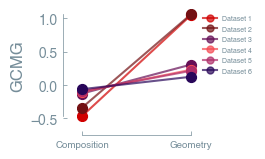

Saved: /Users/n0w0f/git/n0w0f/mattext_nips24/structllm_analysis/PAPER_JOURNAL_01/fig1/property_contribution_dumbbells_palette_earthy_with_name_legend_custom.pdf

Dumbbell plot generated and saved.


In [31]:
json_file_path = "../RESULTS_140925/contribution_analysis.json"


plot_property_contribution_dumbbells(json_file_path)

In [216]:
def plot_contribution_comparison(json_file_path):
    """
    Creates a plot showing composition and geometry contributions on the y-axis
    with properties displayed horizontally. Lines connect the composition and geometry
    contributions for each property, showing the difference.
    
    Args:
        json_file_path (str): The path to the JSON file.
    """
    import json
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from scipy import stats
    
    # Constants for figure size
    TWO_COL_WIDTH_INCH = 8.0
    ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = 5.0
    
    # Hard-coded color map for properties
    PROPERTY_COLORS = {
        "formation_energy_per_atom": "#d73027",     # Red
        "form_energy": "#d73027",                   # Red (alternative name)
        "band_gap": "#fc8d59",                      # Orange
        "bandgap": "#fc8d59",                       # Orange (alternative name)
        "bulk_modulus": "#fee090",                  # Light Orange
        "gvrh": "#fee090",                          # Light Orange (alternative name)
        "gcmg": "#e0f3f8",                          # Light Blue
        "phonons": "#91bfdb",                       # Medium Blue
        "dielectric": "#4575b4",                    # Dark Blue
        "perovskites": "#8c564b",                   # Brown
        "thermal_expansion": "#e377c2",             # Pink
        "hardness": "#7f7f7f",                      # Gray
        "piezoelectric_tensor": "#bcbd22",          # Olive
        "magnetic_moment": "#17becf",               # Cyan
        "refractive_index": "#2ca02c",              # Green
        "poisson_ratio": "#d62728",                 # Bright Red
        # Add more properties as needed
    }
    # Default color for any property not in the map
    DEFAULT_COLOR = "#000000"  # Black
    
    # Function to apply range frame
    def range_frame(ax, x, y, pad=0.1):
        y_min, y_max = y.min(), y.max()
        x_min, x_max = x.min(), x.max()
        ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
        ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
        ax.spines["left"].set_position(("outward", 10))
        ax.spines["bottom"].set_position(("outward", 10))
        ax.spines["bottom"].set_bounds(x_min, x_max)
        ax.spines["left"].set_bounds(y_min, y_max)
    
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file '{json_file_path}' is not a valid JSON file.")
        return

    output_dir = "property_contribution_plots"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Plot will be saved in the '{output_dir}' directory.")

    # --- Step 1: Process and structure data ---
    processed_data = {}  # {property_name: {'comp_values': [], 'geom_values': []}}
    
    for property_name, representations_data in data.items():
        if property_name not in processed_data:
            processed_data[property_name] = {'comp_values': [], 'geom_values': []}
        
        for rep_name, rep_data in representations_data.items():
            if "geometry_contribution" in rep_data and "composition_contribution" in rep_data:
                processed_data[property_name]['geom_values'].append(rep_data["geometry_contribution"])
                processed_data[property_name]['comp_values'].append(rep_data["composition_contribution"])
    
    if not processed_data:
        print("No valid data to plot after processing.")
        return
    
    # Calculate mean values and sort properties
    property_means = {}
    for prop_name, values in processed_data.items():
        if values['comp_values'] and values['geom_values']:
            property_means[prop_name] = {
                'comp_mean': np.mean(values['comp_values']),
                'geom_mean': np.mean(values['geom_values']),
                'diff': np.mean(values['geom_values']) - np.mean(values['comp_values'])
            }
    
    # Sort properties by the difference (descending)
    sorted_properties = sorted(
        property_means.keys(), 
        key=lambda p: property_means[p]['diff'],
        reverse=True
    )
    
    # --- Step 2: Create the plot ---
    fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH))
    
    # Set up x positions - fixed at 0 for comp and 1 for geom
    x_positions = [0, 1]
    
    # Collect all y values for determining plot range
    all_y_values = []
    
    # For legend
    legend_handles = []
    
    # Violin plot parameters
    violin_width = 0.3
    
    # Draw a violin at each composition and geometry position for each property
    for i, prop_name in enumerate(sorted_properties):
        prop_data = processed_data[prop_name]
        means = property_means[prop_name]
        
        # Skip if not enough data
        if len(prop_data['comp_values']) < 1 or len(prop_data['geom_values']) < 1:
            print(f"Warning: Not enough data points for property {prop_name}")
            continue
        
        # Get property color
        color = PROPERTY_COLORS.get(prop_name, DEFAULT_COLOR)
        
        # Collect values for range frame
        comp_values = prop_data['comp_values']
        geom_values = prop_data['geom_values']
        all_y_values.extend(comp_values + geom_values)
        
        # Draw the violin plots for composition
        if len(comp_values) > 1:  # Need at least 2 points for a violin
            v1 = ax.violinplot(
                comp_values, 
                positions=[0], 
                vert=True,
                widths=[violin_width],
                showmeans=False,
                showextrema=False
            )
            # Set colors
            for pc in v1['bodies']:
                pc.set_facecolor(color)
                pc.set_edgecolor('black')
                pc.set_alpha(0.5)
        
        # Draw the violin plots for geometry
        if len(geom_values) > 1:  # Need at least 2 points for a violin
            v2 = ax.violinplot(
                geom_values, 
                positions=[1], 
                vert=True,
                widths=[violin_width],
                showmeans=False,
                showextrema=False
            )
            # Set colors
            for pc in v2['bodies']:
                pc.set_facecolor(color)
                pc.set_edgecolor('black')
                pc.set_alpha(0.5)
        
        # Draw the line connecting the means
        comp_mean = means['comp_mean']
        geom_mean = means['geom_mean']
        ax.plot([0, 1], [comp_mean, geom_mean], '-', color=color, linewidth=2, zorder=10)
        
        # Add small scatter points for the means
        ax.scatter([0, 1], [comp_mean, geom_mean], color=color, s=50, 
                   edgecolor='black', linewidth=0.5, zorder=15)
        
        # Draw scatter points for the individual values with some jitter
        if len(comp_values) <= 10:  # Only draw individual points if not too many
            for val in comp_values:
                # Small horizontal jitter
                jitter = np.random.uniform(-0.03, 0.03)
                ax.scatter(0 + jitter, val, color=color, s=20, alpha=0.6, zorder=5)
                
        if len(geom_values) <= 10:  # Only draw individual points if not too many
            for val in geom_values:
                # Small horizontal jitter
                jitter = np.random.uniform(-0.03, 0.03)
                ax.scatter(1 + jitter, val, color=color, s=20, alpha=0.6, zorder=5)
        
        # Add property name as text in the middle of the line
        text_y = (comp_mean + geom_mean) / 2
        text_x = 0.5
        
        # Only add text labels if fewer than 8 properties to avoid overcrowding
        if len(sorted_properties) < 8:
            ax.text(text_x, text_y, prop_name.replace('_', ' ').title(), 
                    ha='center', va='center', fontsize=8, 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
        
        # Create legend entry
        legend_handles.append(mpatches.Patch(color=color, label=prop_name.replace('_', ' ').title()))
    
    # Apply range frame
    all_y_array = np.array(all_y_values)
    x_array = np.array(x_positions)
    range_frame(ax, x_array, all_y_array, pad=0.1)
    
    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Set axis labels
    ax.set_ylabel('Contribution Value', fontsize=12)
    
    # Set x-ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Composition\nContribution', 'Geometry\nContribution'], fontsize=12)
    
    # Add light grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add legend for properties
    if len(sorted_properties) > 5:  # Use a more compact legend for many properties
        legend_cols = min(3, (len(sorted_properties) + 2) // 3)
        ax.legend(handles=legend_handles, title="Properties", 
                  loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                  ncol=legend_cols, fontsize=8)
    else:
        ax.legend(handles=legend_handles, title="Properties", 
                  loc='best', fontsize=9)
    
    plt.tight_layout()
    
    # Save the plot
    plot_filename = os.path.join(output_dir, "contribution_comparison_plot.png")
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {plot_filename}")
    plt.close(fig)
    
    print("\nContribution comparison plot generated and saved.")

In [218]:

json_file_path = "../RESULTS_140925/contribution_analysis.json"
plot_contribution_comparison(json_file_path)

Plot will be saved in the 'property_contribution_plots' directory.
Saved: property_contribution_plots/contribution_comparison_plot.png

Contribution comparison plot generated and saved.


In [30]:
plt.style.use("lamalab.mplstyle")
def plot_grouped_geometry_composition_coupling(json_file_path):
    """
    Loads data from a JSON file and creates a single grouped bar chart.
    X-axis: Properties (ordered by average contribution in ascending order).
    Groups: Bars for each representation type, showing (geometry_contribution - composition_contribution).

    Args:
        json_file_path (str): The path to the JSON file.
    """
    import json
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.constants import golden
    
    # Constants for figure size
    TWO_COL_WIDTH_INCH = 5.2
    ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH/ 2 *golden
    
    # Hard-coded color map for representations

        
    custom_colors = {
    "form_energy": "#f54952",   # Red
    "bandgap": "#ae2d68",       # Orange
    "dielectric": "#d00000",    # Light Orange
    "gvrh": "#660f56",          # Light Blue
    "phonons": "#731013",       # Medium Blue
    "perovskites": "#280659",   # Dark Blue
    }


    REPRESENTATION_COLORS = {
        "composition": "#fc8d59",     # Orange
        "atom_sequences_plusplus": "#f54952",   # Light Orange
        "slices": "#ae2d68",   # Light Red
        "crystal_text_llm": "#d00000",   # Light Yellow
        "zmatrix": "#660f56",   # Light Purple
        "cif_p1": "#731013",  # Dark Purple
        "atom_sequences": "#e377c2",    # Pink
        "local_env": "#280659",  # Gray
        "gemnet": "#17becf",  # Cyan
        # Add more representations as needed
    }
    # Default color for any representation not in the map
    DEFAULT_COLOR = "#000000"  # Black

    # Hard-coded order for representations
    REPRESENTATION_ORDER = ["composition", "atom_sequences_plusplus", "slices", "crystal_text_llm", "cif_p1", "zmatrix"]
    
    # Function to apply range frame
    def range_frame(ax, x, y, pad=0.1):
        y_min, y_max = y.min(), y.max()
        x_min, x_max = x.min(), x.max()
        ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
        ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
        ax.spines["left"].set_position(("outward", 10))
        ax.spines["bottom"].set_position(("outward", 10))
        ax.spines["bottom"].set_bounds(x_min, x_max)
        ax.spines["left"].set_bounds(y_min, y_max)
    
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file '{json_file_path}' is not a valid JSON file.")
        return

    output_dir = "property_coupling_plots"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Plot will be saved in the '{output_dir}' directory.")

    # --- Step 1: Collect and structure data ---
    # processed_data will look like: {property_name: {representation_name: coupling_value}}
    processed_data = {}
    # Will store property names and their average coupling values for sorting
    property_averages = {}
    all_representation_names_set = set()

    for property_name, representations_data in data.items():
        if property_name not in processed_data:
            processed_data[property_name] = {}
        
        property_coupling_values = []  # To calculate average for this property

        # Sort representation keys for consistent internal order when collecting unique names
        sorted_rep_keys_for_property = sorted(representations_data.keys())

        for rep_key in sorted_rep_keys_for_property:
            rep_data = representations_data[rep_key]
            if "geometry_contribution" in rep_data and "composition_contribution" in rep_data:
                geom_contrib = rep_data["geometry_contribution"]
                comp_contrib = rep_data["composition_contribution"]
                coupling = geom_contrib - comp_contrib
                processed_data[property_name][rep_key] = coupling
                property_coupling_values.append(coupling)
                all_representation_names_set.add(rep_key)
            else:
                print(f"Warning: Missing contribution data for {property_name} -> {rep_key}")
        
        # Calculate average coupling for this property (if we have values)
        if property_coupling_values:
            property_averages[property_name] = sum(property_coupling_values) / len(property_coupling_values)
        else:
            property_averages[property_name] = 0  # Default if no values

    if not processed_data or not all_representation_names_set:
        print("No valid data to plot after processing.")
        return

    # Sort properties by their average coupling values (ascending)
    property_names_ordered = sorted(property_averages.keys(), key=lambda x: property_averages[x])
    
    # Filter to only include representations that are present in the data
    sorted_representation_names = [rep for rep in REPRESENTATION_ORDER if rep in all_representation_names_set]
    # Add any representations that are in the data but not in the predefined order
    sorted_representation_names.extend([rep for rep in sorted(all_representation_names_set) if rep not in REPRESENTATION_ORDER])
    num_properties = len(property_names_ordered)
    num_representations = len(sorted_representation_names)

    if num_properties == 0 or num_representations == 0:
        print("Not enough properties or representations to create a grouped bar chart.")
        return

    # --- Step 2: Plotting ---
    fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, 3))

    # Calculate bar width and positions
    total_width_for_all_bars_in_group = 0.8  # How much of the x-tick space the bars for one property will occupy
    bar_width = total_width_for_all_bars_in_group / num_representations
    
    # X-coordinates for the center of each group (property)
    index = np.arange(num_properties)
    
    # Store all y values to determine range
    all_y_values = []

    for i, rep_name in enumerate(sorted_representation_names):
        coupling_values_for_this_rep = []
        for prop_name in property_names_ordered:
            # Get coupling value, default to 0 if not present for this property/rep combo
            value = processed_data.get(prop_name, {}).get(rep_name, 0)  # Use 0 for missing data
            coupling_values_for_this_rep.append(value)
            all_y_values.append(value)

        # Calculate x-position for this representation's bars across all properties
        bar_positions = index - (total_width_for_all_bars_in_group / 2) + (i * bar_width) + (bar_width / 2)
        
        # Get color for this representation from the color map
        color = REPRESENTATION_COLORS.get(rep_name, DEFAULT_COLOR)
        
        rects = ax.bar(bar_positions, coupling_values_for_this_rep, bar_width,
                      label=rep_name.replace("_", " ").title(),
                      color=color)

    # Apply range frame
    range_frame(ax, np.array(index), np.array(all_y_values), pad=0.08)
    
    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Set x-ticks and labels
    ax.set_xticks(index)
    ax.set_xticklabels([p.replace("_", " ").title() for p in property_names_ordered], rotation=90, ha="center", fontsize=10)
    
    # Place legend outside the plot
    #ax.legend(title="Representations", bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
    ax.legend(ncol=2,loc='upper left', fontsize=6.8)
    #ax.legend( ncol=6, loc='lower left',bbox_to_anchor=(0, -0.45), fontsize=7)
    ax.grid(False)

    plt.tight_layout()

    plot_filename = os.path.join(output_dir, "grouped_property_coupling_v2.pdf")
    plt.savefig(plot_filename, format="pdf")  # Save with higher DPI
    print(f"Saved: {plot_filename}")
    plt.close(fig)

    print("\nGrouped plot generated and saved.")


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [31]:
json_file_path = "../RESULTS_140925/contribution_analysis.json"


plot_grouped_geometry_composition_coupling(json_file_path)

Plot will be saved in the 'property_coupling_plots' directory.
Saved: property_coupling_plots/grouped_property_coupling_v2.pdf

Grouped plot generated and saved.
